In [1]:
#Importing the necessary libraries
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
## Load the data
data=pd.read_csv('Drug_Regulatory_Dataset_50000.csv')

In [5]:
data

,Drug_Name,Manufacturer_Brand,Dosage_mg,Price_Per_Unit,Production_Cost,Marketing_Spend,Clinical_Trial_Phase,Side_Effect_Severity_Score,Abuse_Potential_Score,Prescription_Rate,...,Insurance_Coverage_Percentage,Export_Percentage,Online_Sales_Percentage,Brand_Reputation_Score,Doctor_Recommendation_Rate,Target_Regulatory_Class,Storage_Condition,Distribution_Channel,Approval_Status,Country_of_Origin
0,ViroShield,Pfizer,750,606.54,285.46,319396.32,3,2.40,1.56,0.11,...,21.65,87.29,58.27,2.91,0.22,Regulated Drug,Room Temperature,Hospital,Conditional Approval,UK
1,Paracure,AstraZeneca,100,173.83,94.75,244375.26,4,3.62,6.12,0.18,...,82.81,17.97,36.00,6.33,0.09,Regulated Drug,Cold Storage,Retail,Approved,Japan
2,ViroShield,GSK,1000,65.87,55.30,476998.49,3,9.69,8.08,0.34,...,29.76,44.57,2.41,9.18,0.30,Regulated Drug,Controlled Temperature,Retail,Approved,USA
3,BioHeal,Sun Pharma,1000,177.23,96.95,296019.63,2,2.66,9.70,0.79,...,93.75,7.96,13.72,1.41,0.36,Regulated Drug,Controlled Temperature,Hospital,Conditional Approval,USA
4,GastroEase,Lupin,250,192.23,85.05,210539.00,3,3.53,5.43,0.18,...,81.78,17.88,0.39,8.34,0.72,Regulated Drug,Room Temperature,Online,Approved,Japan
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,Respicure,Pfizer,200,204.65,178.35,209984.53,2,7.15,7.06,0.12,...,94.81,52.56,23.16,7.21,0.14,Regulated Drug,Room Temperature,Hospital,Approved,Japan
49996,ViroShield,Zydus,200,88.87,37.58,181829.49,3,7.13,9.03,0.82,...,34.37,21.49,49.34,3.55,0.18,Non-Regulated Drug,Room Temperature,Retail,Approved,UK
49997,MediPrime,AstraZeneca,200,425.27,266.56,277154.43,4,4.63,2.62,0.76,...,78.36,43.66,31.63,6.03,0.81,Regulated Drug,Room Temperature,Retail,Conditional Approval,Germany
49998,Paracure,Bayer,500,303.89,148.26,403399.70,4,7.01,4.84,0.63,...,22.41,78.00,61.36,4.84,0.36,Regulated Drug,Controlled Temperature,Retail,Approved,USA


In [6]:
# Check shape, column data types, and missing values
data.info()

# Check target variable distribution
print(data['Target_Regulatory_Class'].value_counts())

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 36 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Drug_Name                         50000 non-null  str    
 1   Manufacturer_Brand                50000 non-null  str    
 2   Dosage_mg                         50000 non-null  int64  
 3   Price_Per_Unit                    50000 non-null  float64
 4   Production_Cost                   50000 non-null  float64
 5   Marketing_Spend                   50000 non-null  float64
 6   Clinical_Trial_Phase              50000 non-null  int64  
 7   Side_Effect_Severity_Score        50000 non-null  float64
 8   Abuse_Potential_Score             50000 non-null  float64
 9   Prescription_Rate                 50000 non-null  float64
 10  Hospital_Distribution_Percentage  50000 non-null  float64
 11  Pharmacy_Distribution_Percentage  50000 non-null  float64
 12  Annual_Sales_Vo

In [10]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Define Target and Features
# Dropping high-cardinality/identifier columns like 'Drug_Name' if unnecessary
X = data.drop(columns=['Target_Regulatory_Class', 'Drug_Name'])
y = data['Target_Regulatory_Class']

# 2. Encode Categorical Features in X (e.g., Manufacturer_Brand, Storage_Condition, Approval_Status, etc.)
X = pd.get_dummies(X, drop_first=True)

# 3. Encode Target Column
le = LabelEncoder()
y = le.fit_transform(y)

In [11]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

# 1. Define Target and Features
# Dropping high-cardinality/identifier columns like 'Drug_Name' if unnecessary
X = data.drop(columns=['Target_Regulatory_Class', 'Drug_Name'])
y = data['Target_Regulatory_Class']

# 2. Encode Categorical Features in X (e.g., Manufacturer_Brand, Storage_Condition, Approval_Status, etc.)
X = pd.get_dummies(X, drop_first=True)

# 3. Encode Target Column
le = LabelEncoder()
y = le.fit_transform(y)

In [13]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 2. Feature Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [15]:
from sklearn.linear_model import LogisticRegression

# Initialize and train model
model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lb

Accuracy: 0.5073

Classification Report:
                     precision    recall  f1-score   support

Non-Regulated Drug       0.51      0.49      0.50      4986
    Regulated Drug       0.51      0.53      0.52      5014

          accuracy                           0.51     10000
         macro avg       0.51      0.51      0.51     10000
      weighted avg       0.51      0.51      0.51     10000



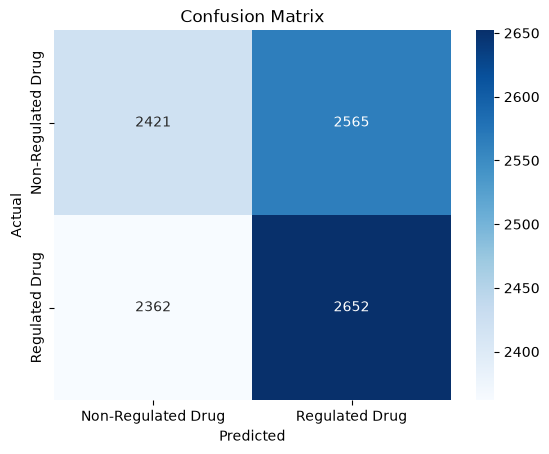

In [16]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predictions
y_pred = model.predict(X_test_scaled)

# Model Performance Summary
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred, target_names=le.classes_))

# Plot Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues', 
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix')
plt.show()

In [17]:
from sklearn.ensemble import RandomForestClassifier

# 1. Random Forest Model Train karein
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)  # Random Forest ke liye scaling ki jarurat nahi hoti

# 2. Evaluate karein
y_pred_rf = rf_model.predict(X_test)
print("Random Forest Accuracy:", accuracy_score(y_test, y_pred_rf))
print("\nClassification Report:\n", classification_report(y_test, y_pred_rf, target_names=le.classes_))

Random Forest Accuracy: 0.5036

Classification Report:
                     precision    recall  f1-score   support

Non-Regulated Drug       0.50      0.52      0.51      4986
    Regulated Drug       0.51      0.49      0.50      5014

          accuracy                           0.50     10000
         macro avg       0.50      0.50      0.50     10000
      weighted avg       0.50      0.50      0.50     10000

